In [12]:
import pandas as pd
import numpy as np

DATA_PATH = "Dataset/"

orders = pd.read_csv(DATA_PATH + "olist_orders_dataset.csv")
items = pd.read_csv(DATA_PATH + "olist_order_items_dataset.csv")
reviews = pd.read_csv(DATA_PATH + "olist_order_reviews_dataset.csv")
customers = pd.read_csv(DATA_PATH + "olist_customers_dataset.csv")
sellers = pd.read_csv(DATA_PATH + "olist_sellers_dataset.csv")

print("orders:", orders.shape)
print("items:", items.shape)
print("reviews:", reviews.shape)
print("customers:", customers.shape)
print("sellers:", sellers.shape)

orders: (99441, 8)
items: (112650, 7)
reviews: (99224, 7)
customers: (99441, 5)
sellers: (3095, 4)


In [13]:
# Join core tables
df = (
    orders
    .merge(items, on="order_id", how="inner")
    .merge(reviews[["order_id", "review_score"]], on="order_id", how="left")
    .merge(customers[["customer_id", "customer_unique_id"]], on="customer_id", how="left")
    .merge(sellers[["seller_id"]], on="seller_id", how="left")
)

print(df.shape)
df.head()

(113314, 16)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,review_score,customer_unique_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,4.0,7c396fd4830fd04220f754e42b4e5bff
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,4.0,af07308b275d755c9edb36a90c618231
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,5.0,3a653a41f6f9fc3d2a113cf8398680e8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,5.0,7c142cf63193a1473d2e66489a9ae977
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,5.0,72632f0f9dd73dfee390c9b22eb56dd6


In [14]:
# Convert date columns to datetime
date_cols = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df["delivery_delay"] = (
    df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
).dt.days

df["order_month"] = df["order_purchase_timestamp"].dt.to_period("M").astype(str)
# We get the negative number as delivery ahead and positive as delayed
print(df["delivery_delay"].describe())
print(df["review_score"].describe())
print(df["price"].describe())

count    110839.000000
mean        -12.035809
std          10.159965
min        -147.000000
25%         -17.000000
50%         -13.000000
75%          -7.000000
max         188.000000
Name: delivery_delay, dtype: float64
count    112372.000000
mean          4.032473
std           1.387849
min           1.000000
25%           4.000000
50%           5.000000
75%           5.000000
max           5.000000
Name: review_score, dtype: float64
count    113314.000000
mean        120.478701
std         183.279678
min           0.850000
25%          39.900000
50%          74.900000
75%         134.900000
max        6735.000000
Name: price, dtype: float64


Here we have two problem.
- First we figure out the avg differentiation is about 12 days which is too ideally, maybe the reason could be the estimated day we set is pretty conservative.
- Second the extreme value for max and min is 188 days and - 147 days looks like the cluster.

So we need to do some adjustment for the dataset first.

In [15]:
# Clip to standardize the delivery delay, we consider the delivery ahead more than 30 days and delayed more than 60 days as outliers.
df["delivery_delay"] = df["delivery_delay"].clip(-30, 60)

#clip the review score,
df["good_review"] = df["review_score"] >= 4

# Clip the review score
df["review_score"] = df["review_score"].clip(1, 5)

# I log-transformed price to handle skewness
df["log_price"] = np.log1p(df["price"])

print(df["delivery_delay"].describe())
print(df["review_score"].describe())
print(df["log_price"].describe())

count    110839.000000
mean        -11.883344
std           9.240836
min         -30.000000
25%         -17.000000
50%         -13.000000
75%          -7.000000
max          60.000000
Name: delivery_delay, dtype: float64
count    112372.000000
mean          4.032473
std           1.387849
min           1.000000
25%           4.000000
50%           5.000000
75%           5.000000
max           5.000000
Name: review_score, dtype: float64
count    113314.000000
mean          4.336043
std           0.907807
min           0.615186
25%           3.711130
50%           4.329417
75%           4.911919
max           8.815222
Name: log_price, dtype: float64


In [16]:
# create month
df["order_month"] = pd.to_datetime(df["order_purchase_timestamp"]).dt.to_period("M").astype(str)

# aggregate
agg_df = df.groupby(["seller_id", "order_month"]).agg({
    "price": "sum",
    "delivery_delay": "mean",
    "review_score": "mean",
    "order_id": "nunique"
}).reset_index()

agg_df.rename(columns={
    "price": "gmv", # Gross Merchandise Value
    "delivery_delay": "avg_delay",
    "review_score": "avg_review",
    "order_id": "order_count"
}, inplace=True)

print(agg_df.shape)
agg_df.head()

(16441, 6)


,seller_id,order_month,gmv,avg_delay,avg_review,order_count
0,0015a82c2db000af6aaaf3ae2ecb0532,2017-09,895.0,-23.000000,5.000000,1
1,0015a82c2db000af6aaaf3ae2ecb0532,2017-10,1790.0,-13.000000,3.000000,2
2,001cca7ae9ae17fb1caed9dfb1094831,2017-02,1098.9,-21.090909,4.272727,5
3,001cca7ae9ae17fb1caed9dfb1094831,2017-03,1676.7,-10.588235,3.117647,11
4,001cca7ae9ae17fb1caed9dfb1094831,2017-04,1847.2,-14.733333,3.687500,14


In [ ]:
# Number of orders per customer for each seller
customer_orders = df.groupby(["seller_id", "customer_unique_id"])["order_id"].nunique().reset_index()

# Indicate whether the customer is a repeat customer
customer_orders["is_repeat_customer"] = customer_orders["order_id"] > 1

# Find repeat customers
repeat_customers = customer_orders[customer_orders["is_repeat_customer"]]

# Find the orders contributed by these repeat customers
repeat_orders = df.merge(
    repeat_customers[["seller_id", "customer_unique_id"]],
    on=["seller_id", "customer_unique_id"],
    how="inner"
)

# Count the number of orders
total_orders = df.groupby("seller_id")["order_id"].nunique().reset_index(name="total_orders")
repeat_orders_count = repeat_orders.groupby("seller_id")["order_id"].nunique().reset_index(name="repeat_orders")

# merge
repeat_rate = total_orders.merge(repeat_orders_count, on="seller_id", how="left")
repeat_rate["repeat_orders"] = repeat_rate["repeat_orders"].fillna(0)

# final repeat rate
repeat_rate["repeat_rate"] = repeat_rate["repeat_orders"] / repeat_rate["total_orders"]

repeat_rate = repeat_rate[["seller_id", "repeat_rate"]]


In [19]:
agg_df = agg_df.drop(columns=["repeat_rate"], errors='ignore')
agg_df = agg_df.merge(repeat_rate, on="seller_id", how="left")

agg_df.describe()

,gmv,avg_delay,avg_review,order_count,repeat_rate
count,16441.000000,16066.000000,16406.000000,16441.000000,16441.000000
mean,830.358462,-12.364094,4.067620,6.082963,0.014542
std,1891.524994,7.921023,1.060287,12.752703,0.043852
min,2.290000,-30.000000,1.000000,1.000000,0.000000
25%,116.700000,-16.600000,3.706495,1.000000,0.000000
50%,298.000000,-12.500000,4.333333,2.000000,0.000000
75%,779.000000,-8.272727,5.000000,6.000000,0.008996
max,64337.560000,60.000000,5.000000,271.000000,1.000000


We notice that the mean of the repeat_rate(# repeat orders / # total orders) is 0.01 which is a little bit low,but it is much better than my previous metric # repeat customer / # total customer (that one is about 0.007),the normal result should lie between 0.05-0.3.

In this case, we need to propose a new design.
Retention Metrics:

1. repeat_rate（weak signal）
2. good_review_rate（strong proxy）
delivery → good_review → repeat

Repeat purchase rate was extremely low due to dataset structure, so I introduced review-based retention as a proxy to better capture customer satisfaction and future behavior.

In [24]:
good_review_rate = df.groupby(["seller_id", "order_month"])["good_review"].mean().reset_index()
good_review_rate.rename(columns={"good_review": "good_review_rate"}, inplace=True)
agg_df = agg_df.drop(columns=[col for col in agg_df.columns if "good_review" in col], errors="ignore")

agg_df = agg_df.merge(good_review_rate, on=["seller_id", "order_month"], how="left")
agg_df.describe()

,gmv,avg_delay,avg_review,order_count,repeat_rate,good_review_rate
count,16441.000000,16066.000000,16406.000000,16441.000000,16441.000000,16441.000000
mean,830.358462,-12.364094,4.067620,6.082963,0.014542,0.760696
std,1891.524994,7.921023,1.060287,12.752703,0.043852,0.321164
min,2.290000,-30.000000,1.000000,1.000000,0.000000,0.000000
25%,116.700000,-16.600000,3.706495,1.000000,0.000000,0.627451
50%,298.000000,-12.500000,4.333333,2.000000,0.000000,0.916667
75%,779.000000,-8.272727,5.000000,6.000000,0.008996,1.000000
max,64337.560000,60.000000,5.000000,271.000000,1.000000,1.000000


We measure the retention by the good_review_rate(0.76) which in this case, equivalent to the customer satisfaction to quantify the retention. In my previous metric design, we make the retension equals to the repeat purchase results in pretty low mean (0.014).

From the result, mean ≈ 0.76,median ≈ 0.91,we can conclude that most of the orders are good experience,but the std = 0.32 means there is huge difference between the Merchant. (min=0, some merchants are pretty bad in this case, almost bad rating.)


All in all, Repeat purchase was extremely sparse due to dataset structure, so I introduced review-based retention as a proxy. This allowed me to capture customer satisfaction at the order level, which is more observable and provides a stronger signal for merchant performance.

Define the health Score, Health Score = Metrics that assess a business’s health + inform decision-making

we want avg_delay = negative metric - smaller the better
others (avg_review, good_review_rate,gmv) - lager the better

In [ ]:
# Now we standardize the dataframe

from sklearn.preprocessing import StandardScaler

features = ["avg_delay", "avg_review", "good_review_rate", "gmv"]

scaler = StandardScaler() 
# make the value near the mean to 0 and outlier to huge positive number or huge negative number

scaled = scaler.fit_transform(agg_df[features])

scaled_df = pd.DataFrame(scaled, columns=[f"{col}_scaled" for col in features])

agg_df = pd.concat([agg_df, scaled_df], axis=1)



In [ ]:
# Negative metrics
agg_df["avg_delay_scaled"] = -agg_df["avg_delay_scaled"]

In [27]:
agg_df["health_score"] = (
    0.4 * agg_df["good_review_rate_scaled"] +
    0.3 * agg_df["avg_review_scaled"] +
    0.2 * agg_df["avg_delay_scaled"] +
    0.1 * agg_df["gmv_scaled"]
)

In [28]:
agg_df["health_score"].describe()

count    16038.000000
mean         0.037716
std          0.723156
min         -3.684427
25%         -0.237587
50%          0.280894
75%          0.523259
max          3.572589
Name: health_score, dtype: float64

In [30]:
print("TOP merchants:")
display(agg_df.sort_values("health_score", ascending=False).head())

print("BOTTOM merchants:")
display(agg_df.sort_values("health_score", ascending=True).head())

TOP merchants:


,seller_id,order_month,gmv,avg_delay,avg_review,order_count,repeat_rate,good_review_rate,avg_delay_scaled,avg_review_scaled,good_review_rate_scaled,gmv_scaled,health_score
5498,53243585a1d6dc2643021fd1853d8905,2017-09,64337.56,-10.651163,4.477273,83,0.044693,0.875000,-0.216258,0.386372,0.355916,33.575625,3.572589
5499,53243585a1d6dc2643021fd1853d8905,2017-10,41708.00,-13.160000,4.320000,49,0.044693,0.823529,0.100483,0.238037,0.195649,21.611602,2.330927
5497,53243585a1d6dc2643021fd1853d8905,2017-08,34576.00,-11.625000,4.117647,34,0.044693,0.823529,-0.093311,0.047184,0.195649,17.840984,1.857851
8318,7d13fca15225358621be4086e1eb0964,2018-05,31564.81,-10.971831,4.084112,206,0.003540,0.780374,-0.175774,0.015555,0.061272,16.248998,1.618920
8454,7e93a43ef30c4f03f38b393420bc753a,2017-05,25401.47,-15.175000,4.380952,42,0.000000,0.833333,0.354878,0.295525,0.226176,12.990502,1.549154


BOTTOM merchants:


,seller_id,order_month,gmv,avg_delay,avg_review,order_count,repeat_rate,good_review_rate,avg_delay_scaled,avg_review_scaled,good_review_rate_scaled,gmv_scaled,health_score
14373,df683dfda87bf71ac3fc63063fba369d,2017-03,39.90,60.0,1.0,1,0.0,0.0,-9.135985,-2.893286,-2.368635,-0.417908,-3.684427
15135,ebef8d8c92b4fd3226e5d407bbff21ac,2017-01,69.90,60.0,1.0,1,0.0,0.0,-9.135985,-2.893286,-2.368635,-0.402047,-3.682841
7612,72146da5774cabf2632faedcae097a76,2018-03,69.99,60.0,1.0,1,0.0,0.0,-9.135985,-2.893286,-2.368635,-0.401999,-3.682837
7273,6f1a1263039c76e68f40a8e536b1da6a,2018-01,77.70,60.0,1.0,2,0.0,0.0,-9.135985,-2.893286,-2.368635,-0.397923,-3.682429
14436,e09887ca8c7bf8a4621ce481820414ef,2017-11,79.98,60.0,1.0,2,0.0,0.0,-9.135985,-2.893286,-2.368635,-0.396718,-3.682308


We can see for the top merchants, the good_review_rate = 0.87,avg_review_scaled > 0,avg_delay_scaled close to 0 and gmv_scaled is pretty high （33 / 21 / 17）

for the bottom merchants, the good_review_rate = 0, avg_review_scaled ≈ -2.89, avg_delay_scaled ≈ -9.13 and gmv_scaled is quite low which follow the logic.

In this case, I constructed a merchant health score by combining customer satisfaction, operational efficiency, and business performance. I normalized each metric, aligned their direction, and weighted them based on their relevance to retention

So.  we can conclude that:
 1. Customer satisfaction (good_review_rate)  is the strongest signal so far. Since Merchants with high health scores have high ratings while Merchants with low health scores → All have around 0 rating.

 2. Delivery is the key driver since bottom merchant → delay bad, and avg_delay_scaled = -9

 3. GMV amplifies health, but it is not the determining factor since Merchants with high GMV are more likely to rank at the top. But if their reviews are poor, they will still drop in rankings.

In this senario, we need to do some drive analysis to think of why some of the merchant health is bad.


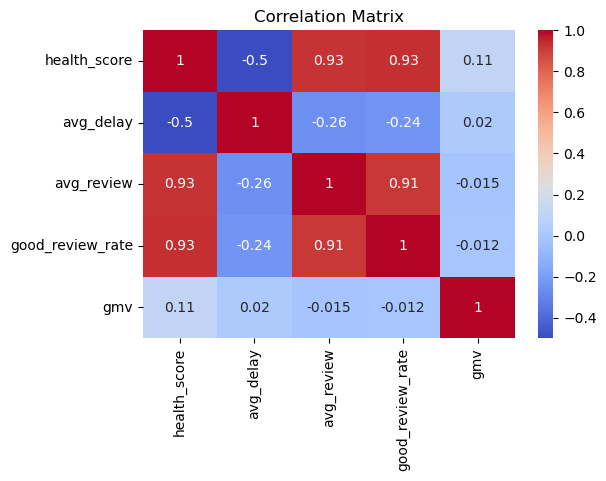

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
# Compute the correlation matrix
corr = agg_df[[
    "health_score",
    "avg_delay",
    "avg_review",
    "good_review_rate",
    "gmv"
]].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()